### Front matter

---
### exercise: resolucao_data
### ai_use: "Gemini no código; a análise é minha."
---

# Exercício 1
## A — Gere as nuvens e B — Mais ou menos espalhado

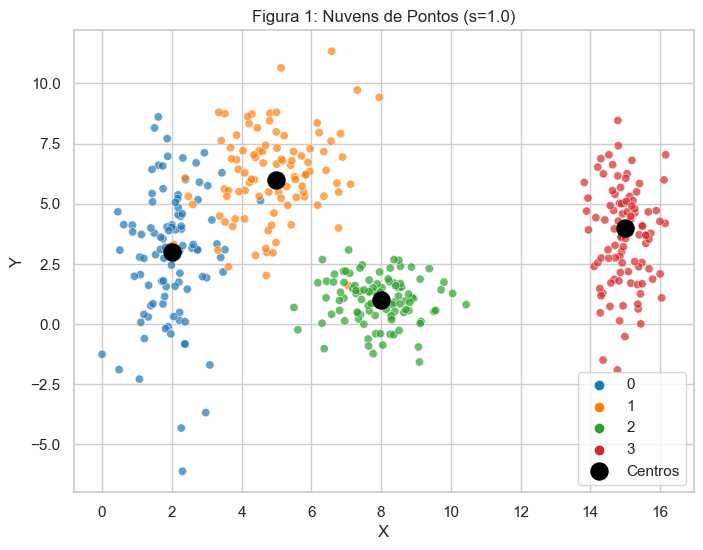

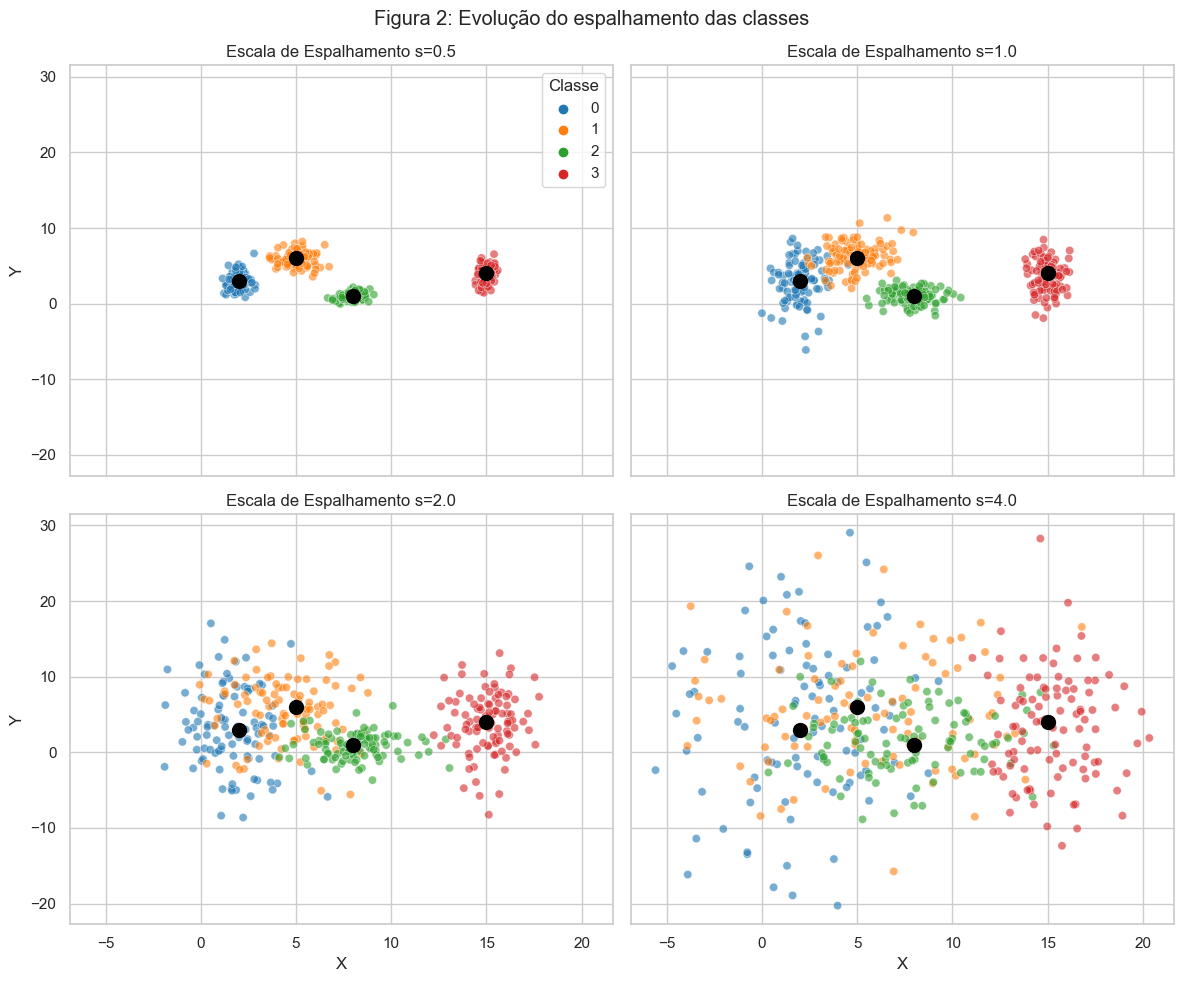

Razão de separação para s=1.0:
Par (0, 1): 1.3258
Par (0, 2): 2.4802
Par (0, 3): 4.4960
Par (1, 2): 2.3800
Par (1, 3): 3.6422
Par (2, 3): 3.5422

Menor r_ij em s=1.0: 1.3258 (Par (0, 1))
Menor r_ij em s=2.0 (escala com 1/s): 0.6629
Taxa de mistura (s=0.5): 0.0025
Taxa de mistura (s=1.0): 0.0725
Taxa de mistura (s=2.0): 0.1925
Taxa de mistura (s=4.0): 0.4825


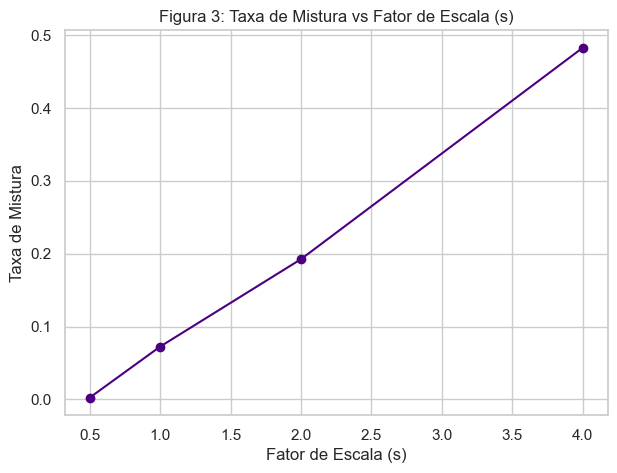

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração inicial exigida
rng = np.random.default_rng(42)
sns.set_theme(style="whitegrid")

# Parâmetros base (s=1)
medias = np.array([
    [2, 3],
    [5, 6],
    [8, 1],
    [15, 4]
])
desvios_base = np.array([
    [0.8, 2.5],
    [1.2, 1.9],
    [0.9, 0.9],
    [0.5, 2.0]
])

escalas = [0.5, 1.0, 2.0, 4.0]
n_amostras = 100
dados_dit = {}

# Geração de todos os datasets
for s in escalas:
    df_lista = []
    for c in range(4):
        pontos = rng.normal(loc=medias[c], scale=desvios_base[c] * s, size=(n_amostras, 2))
        df_temp = pd.DataFrame(pontos, columns=['X', 'Y'])
        df_temp['Classe'] = c
        df_lista.append(df_temp)
    dados_dit[s] = pd.concat(df_lista, ignore_index=True)

# A - Figura 1: Dataset original (s=1.0)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dados_dit[1.0], x='X', y='Y', hue='Classe', palette='tab10', alpha=0.7)
plt.scatter(medias[:, 0], medias[:, 1], color='black', marker='o', s=150, label='Centros')
plt.title("Figura 1: Nuvens de Pontos (s=1.0)")
plt.legend()
plt.show()

# B - Figura 2: 4 subplots compartilhando eixos
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, s in enumerate(escalas):
    sns.scatterplot(data=dados_dit[s], x='X', y='Y', hue='Classe', palette='tab10', ax=axes[i], legend=(i==0), alpha=0.6)
    axes[i].scatter(medias[:, 0], medias[:, 1], color='black', marker='o', s=100)
    axes[i].set_title(f"Escala de Espalhamento s={s}")

plt.suptitle("Figura 2: Evolução do espalhamento das classes")
plt.tight_layout()
plt.show()

# B - Cálculo da razão de separação r_ij para s=1
def calcula_r_ij(i, j, s=1.0):
    distancia = np.linalg.norm(medias[i] - medias[j])
    sigma_bar_i = np.mean(desvios_base[i] * s)
    sigma_bar_j = np.mean(desvios_base[j] * s)
    return distancia / (sigma_bar_i + sigma_bar_j)

print("Razão de separação para s=1.0:")
r_min = float('inf')
par_min = None
for i in range(4):
    for j in range(i+1, 4):
        r = calcula_r_ij(i, j, s=1.0)
        print(f"Par ({i}, {j}): {r:.4f}")
        if r < r_min:
            r_min = r
            par_min = (i, j)
            
print(f"\nMenor r_ij em s=1.0: {r_min:.4f} (Par {par_min})")
print(f"Menor r_ij em s=2.0 (escala com 1/s): {r_min / 2:.4f}")

# B - Taxa de mistura
taxas_mistura = []
for s in escalas:
    df = dados_dit[s]
    pontos = df[['X', 'Y']].values
    classes_verdadeiras = df['Classe'].values
    
    distancias = np.linalg.norm(pontos[:, np.newaxis, :] - medias, axis=2)
    classes_preditas = np.argmin(distancias, axis=1)
    
    erros = np.sum(classes_preditas != classes_verdadeiras)
    taxa = erros / len(df)
    taxas_mistura.append(taxa)
    print(f"Taxa de mistura (s={s}): {taxa:.4f}")

# Figura 3: Gráfico Taxa de Mistura x s
plt.figure(figsize=(7, 5))
plt.plot(escalas, taxas_mistura, marker='o', linestyle='-', color='indigo')
plt.title("Figura 3: Taxa de Mistura vs Fator de Escala (s)")
plt.xlabel("Fator de Escala (s)")
plt.ylabel("Taxa de Mistura")
plt.grid(True)
plt.show()

### C — Análise
1. **Sobreposição no dataset original (s=1):** A No primeiro caso, os dados quase não se misturam exceto um pouco entre as classes 0 e 1. Não dá para separar 4 grupos usando uma linha reta só. A gente precisa de várias retas se cruzando, para isolar cada grupo no seu espaço
2. **Esboço (para o relatório):** Se você traçar linhas dividindo o meio de cada grupo, vai formar um mosaico
3. **Relação com o item B:** Se a gente aumenta o espalhamento (aumenta o s), os dados de cada grupo começam a espalhar e invadir o espaço do vizinho. Como os grupos estão muito misturados fisicamente, ou seja, qualquer modelo vai errar mais porque estão integrados

# Exercício 2
## A e B — Geração dos Datasets

In [ ]:
from sklearn.decomposition import PCA

# Dataset I: Gaussianas Deslocadas
mu_A = np.zeros(5)
cov_A = np.array([
    [1.0, 0.8, 0.1, 0.0, 0.0],
    [0.8, 1.0, 0.3, 0.0, 0.0],
    [0.1, 0.3, 1.0, 0.5, 0.0],
    [0.0, 0.0, 0.5, 1.0, 0.2],
    [0.0, 0.0, 0.0, 0.2, 1.0]
])

mu_B = np.full(5, 1.5)
cov_B = np.array([
    [ 1.5, -0.7,  0.2,  0.0,  0.0],
    [-0.7,  1.5,  0.4,  0.0,  0.0],
    [ 0.2,  0.4,  1.5,  0.6,  0.0],
    [ 0.0,  0.0,  0.6,  1.5,  0.3],
    [ 0.0,  0.0,  0.0,  0.3,  1.5]
])

amostras_A = rng.multivariate_normal(mu_A, cov_A, 500)
amostras_B = rng.multivariate_normal(mu_B, cov_B, 500)
df_I = pd.DataFrame(np.vstack((amostras_A, amostras_B)), columns=[f'F{i}' for i in range(1, 6)])
df_I['Classe'] = ['A']*500 + ['B']*500

# Dataset II: Cascas Concêntricas
v_C = rng.standard_normal((500, 5))
u_C = v_C / np.linalg.norm(v_C, axis=1, keepdims=True)
raios_C = rng.normal(2.0, 0.4, 500)
amostras_C = u_C * raios_C[:, np.newaxis]

v_D = rng.standard_normal((500, 5))
u_D = v_D / np.linalg.norm(v_D, axis=1, keepdims=True)
raios_D = rng.normal(5.0, 0.4, 500)
amostras_D = u_D * raios_D[:, np.newaxis]

df_II = pd.DataFrame(np.vstack((amostras_C, amostras_D)), columns=[f'F{i}' for i in range(1, 6)])
df_II['Classe'] = ['C']*500 + ['D']*500

## C — Visualize e compare

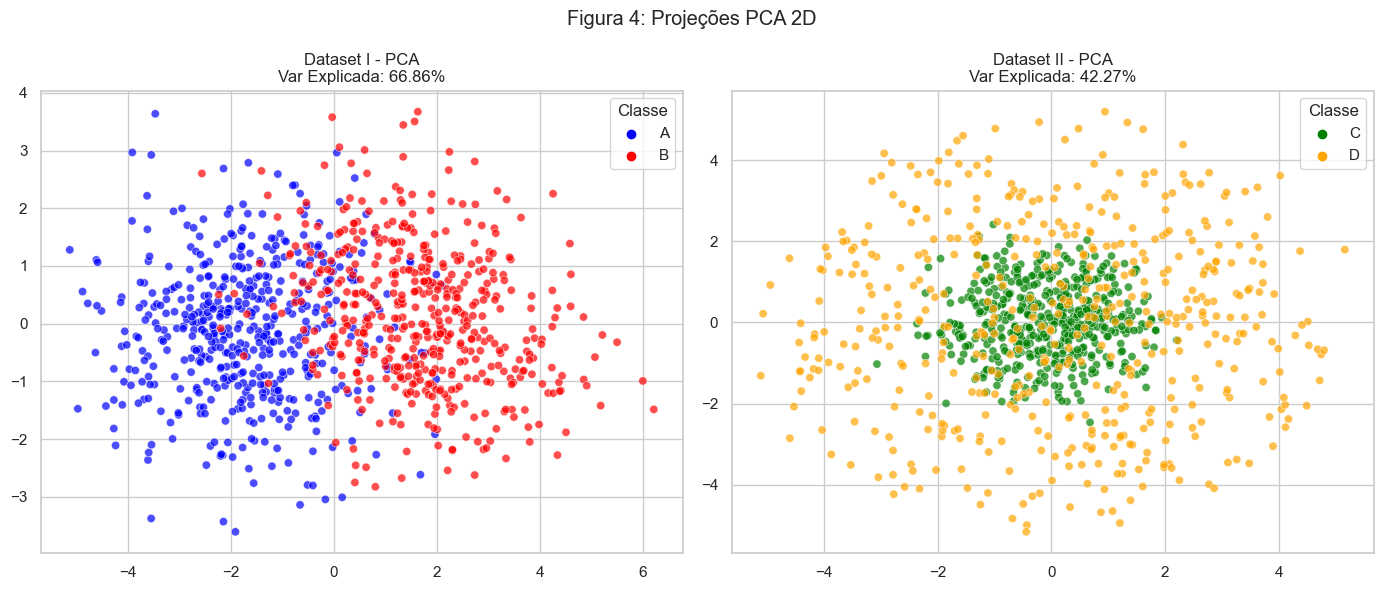

Var explicada Dataset I: 0.6686
Var explicada Dataset II: 0.4227
Distância entre centros (Dataset I): 3.4056
Distância entre centros (Dataset II): 0.2215


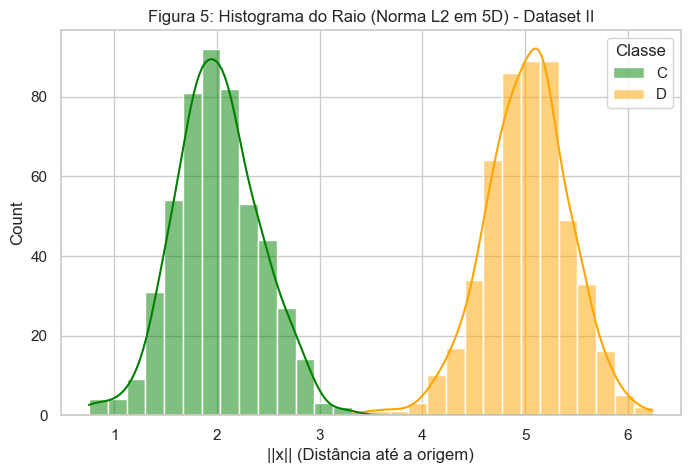

In [ ]:
# PCA e Figura 4
pca_I = PCA(n_components=2)
proj_I = pca_I.fit_transform(df_I.drop('Classe', axis=1))

pca_II = PCA(n_components=2)
proj_II = pca_II.fit_transform(df_II.drop('Classe', axis=1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=proj_I[:,0], y=proj_I[:,1], hue=df_I['Classe'], palette=['blue', 'red'], ax=ax1, alpha=0.7)
ax1.set_title(f"Dataset I - PCA\nVar Explicada: {np.sum(pca_I.explained_variance_ratio_):.2%}")

sns.scatterplot(x=proj_II[:,0], y=proj_II[:,1], hue=df_II['Classe'], palette=['green', 'orange'], ax=ax2, alpha=0.7)
ax2.set_title(f"Dataset II - PCA\nVar Explicada: {np.sum(pca_II.explained_variance_ratio_):.2%}")

plt.suptitle("Figura 4: Projeções PCA 2D")
plt.tight_layout()
plt.show()

print(f"Var explicada Dataset I: {np.sum(pca_I.explained_variance_ratio_):.4f}")
print(f"Var explicada Dataset II: {np.sum(pca_II.explained_variance_ratio_):.4f}")

# Distâncias 5D e Figura 5
dist_I = np.linalg.norm(np.mean(amostras_A, axis=0) - np.mean(amostras_B, axis=0))
dist_II = np.linalg.norm(np.mean(amostras_C, axis=0) - np.mean(amostras_D, axis=0))

print(f"Distância entre centros (Dataset I): {dist_I:.4f}")
print(f"Distância entre centros (Dataset II): {dist_II:.4f}")

df_II['Raio_5D'] = np.linalg.norm(df_II.drop('Classe', axis=1), axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(data=df_II, x='Raio_5D', hue='Classe', palette=['green', 'orange'], kde=True, bins=30)
plt.title("Figura 5: Histograma do Raio (Norma L2 em 5D) - Dataset II")
plt.xlabel("||x|| (Distância até a origem)")
plt.show()

### D — Análise
1. **Hiperplanos e centros coincidentes:** Um grupo é o "miolo" e o outro é a "casca" em volta dele. Ou seja, os dois têm o mesmo centro. Nenhuma linha reta consegue cortar isso e deixar o miolo de um lado e a casca do outro
2. **Inseparabilidade linear:** Como o formato é tipo uma esfera, se você passar uma reta, vai acabar fatiando o miolo e a casca juntos
3. **PCA e projeção:** O PCA meio que "espreme" os dados para criar o gráfico e acaba perdendo a noção do tamanho da bolha. Para separar esses dados com perfeição, é só olhar para a distância do centro (o raio). Se a distância for menor que um certo valor (tipo 3.5), é o miolo (Classe C). Se for maior, é a casca (Classe D)

# Exercício 3
## Pré-processamento e análise de dados (Spaceship Titanic)


--- PARTE A: ANÁLISE INICIAL ---
Balanceamento de 'Transported':
Transported
True     50.362361
False    49.637639
Name: proportion, dtype: float64

Valores faltantes por coluna:
              Contagem  Percentual (%)
HomePlanet         201            2.31
CryoSleep          217            2.50
Cabin              199            2.29
Destination        182            2.09
Age                179            2.06
VIP                203            2.34
RoomService        181            2.08
FoodCourt          183            2.11
ShoppingMall       208            2.39
Spa                183            2.11
VRDeck             188            2.16
Name               200            2.30

Estatísticas das colunas de gasto:
        RoomService  FoodCourt  ShoppingMall       Spa    VRDeck
mean         224.69     458.08        173.73    311.14    304.85
median         0.00       0.00          0.00      0.00      0.00
max        14327.00   29813.00      23492.00  22408.00  24133.00

--- PARTE D: VERI

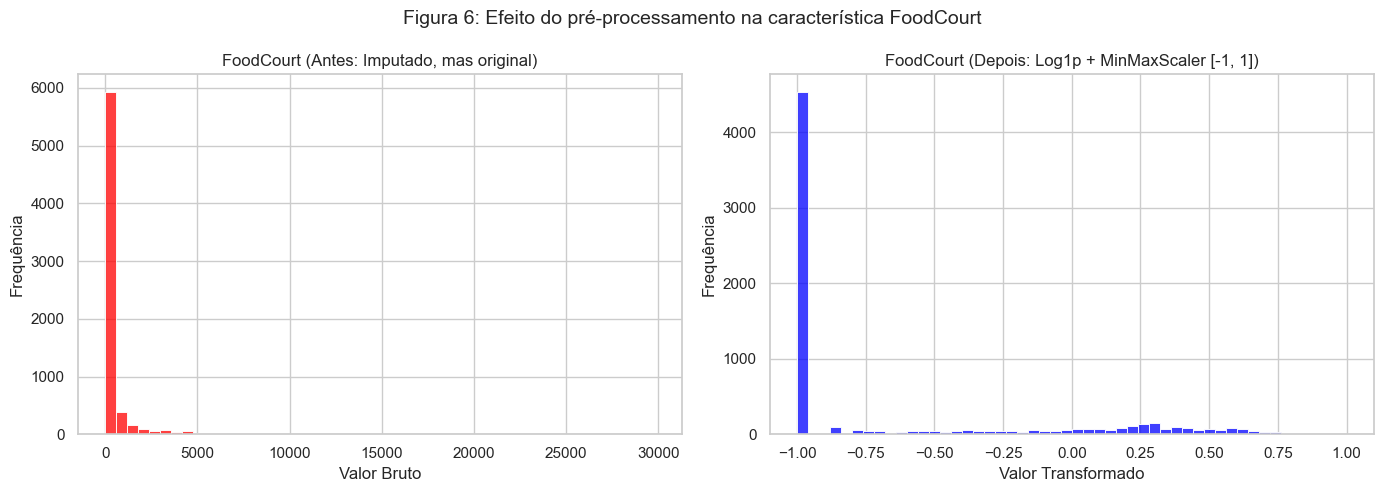

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

# Configurações visuais
sns.set_theme(style="whitegrid")

# PARTE A - Conheça os dados
print("--- PARTE A: ANÁLISE INICIAL ---")
df = pd.read_csv('train.csv')

# 1. Proporção e balanceamento do alvo
alvo_prop = df['Transported'].value_counts(normalize=True) * 100
print(f"Balanceamento de 'Transported':\n{alvo_prop}\n")

# 2. Tabela de valores faltantes
df_faltantes = pd.DataFrame({
    'Contagem': df.isnull().sum(),
    'Percentual (%)': (df.isnull().mean() * 100).round(2)
})
print(f"Valores faltantes por coluna:\n{df_faltantes[df_faltantes['Contagem'] > 0]}\n")

# 3. Estatísticas de Gasto
colunas_gasto = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
stats_gasto = df[colunas_gasto].agg(['mean', 'median', 'max']).round(2)
print(f"Estatísticas das colunas de gasto:\n{stats_gasto}\n")


# PARTE B - Separe antes de transformar
X = df.drop(columns=['Transported', 'PassengerId', 'Name', 'Cabin'])
y = df['Transported']

# Divisão 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# PARTE C - Pré-processe
colunas_cat = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
colunas_num = ['Age'] + colunas_gasto

# 1. Imputação (ajustada APENAS no treino)
imp_num = SimpleImputer(strategy='median')
imp_cat = SimpleImputer(strategy='most_frequent')

X_train_num = pd.DataFrame(imp_num.fit_transform(X_train[colunas_num]), columns=colunas_num)
X_test_num  = pd.DataFrame(imp_num.transform(X_test[colunas_num]), columns=colunas_num)

X_train_cat = pd.DataFrame(imp_cat.fit_transform(X_train[colunas_cat]), columns=colunas_cat)
X_test_cat  = pd.DataFrame(imp_cat.transform(X_test[colunas_cat]), columns=colunas_cat)

# 2. Encoding das categóricas
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_enc = pd.DataFrame(encoder.fit_transform(X_train_cat), columns=encoder.get_feature_names_out())
X_test_enc  = pd.DataFrame(encoder.transform(X_test_cat), columns=encoder.get_feature_names_out())

# 3. Engenharia de features: TotalSpend
X_train_num['TotalSpend'] = X_train_num[colunas_gasto].sum(axis=1)
X_test_num['TotalSpend']  = X_test_num[colunas_gasto].sum(axis=1)

foodcourt_antes = X_train_num['FoodCourt'].copy()
media_fc_antes = foodcourt_antes.mean()
mediana_fc_antes = foodcourt_antes.median()

# 4. Cauda pesada: Transformação Logarítmica log(1+x)
for col in colunas_gasto + ['TotalSpend']:
    X_train_num[col] = np.log1p(X_train_num[col])
    X_test_num[col]  = np.log1p(X_test_num[col])

# 5. Escalonamento para [-1, 1] com MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_num), columns=X_train_num.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_num), columns=X_test_num.columns)

# Matrizes Finais unificadas
X_train_final = pd.concat([X_train_scaled, X_train_enc], axis=1)
X_test_final  = pd.concat([X_test_scaled, X_test_enc], axis=1)


# PARTE D - Verifique e visualize
print("--- PARTE D: VERIFICAÇÕES FINAIS ---")
print(f"NaN restantes no Treino: {X_train_final.isna().sum().sum()}")
print(f"Shape de X_train_final: {X_train_final.shape}")
print(f"Treino - Min: {X_train_final.values.min():.4f} | Max: {X_train_final.values.max():.4f}")
print(f"Teste  - Min: {X_test_final.values.min():.4f} | Max: {X_test_final.values.max():.4f}\n")

# Figura 6: FoodCourt Antes vs Depois
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(foodcourt_antes, bins=50, kde=False, ax=ax1, color='red')
ax1.set_title("FoodCourt (Antes: Imputado, mas original)")
ax1.set_xlabel("Valor Bruto")
ax1.set_ylabel("Frequência")

sns.histplot(X_train_final['FoodCourt'], bins=50, kde=False, ax=ax2, color='blue')
ax2.set_title("FoodCourt (Depois: Log1p + MinMaxScaler [-1, 1])")
ax2.set_xlabel("Valor Transformado")
ax2.set_ylabel("Frequência")

plt.suptitle("Figura 6: Efeito do pré-processamento na característica FoodCourt", fontsize=14)
plt.tight_layout()
plt.show()

### D3 — Reflexão Final
A grande sacada antes de jogar os dados na rede neural foi usar o logaritmo junto com o ajustador de escala (MinMaxScaler). Pois. se a gente não usasse o log, aquele passageiro que gastou uma fortuna ia esticar tanto a régua do gráfico que as pessoas "normais" iam ficar todas espremidas num cantinho só (perto do zero). Com todo mundo esmagado, a rede neural não ia conseguir enxergar a diferença entre os passageiros comuns e ia aprender super mal. O log resolve isso "puxando" quem tá muito longe e espalhando melhor quem tá perto